# Baseline Solution - Monte Carlo Dropout

## This notebook documents the baseline solution for ADC 2023. 

## Overview
Our challenge is to provide a conditional probability distribution for each target (7 in total) given an observation from the Ariel Space Telescope. 

Depending on the information content of the observation and the associated observation noise (which is a function of the instrument and the planetary system), the resultant error bounds on each target and their joint conditional distribution will be different.

There are many directions you can take to tackle the problem on hand. We would like to get you started with our baseline solution. Inside this notebook you will find the setup for the baseline model, ways to compute the competition score and how to package the output into the competition format.

Spectroscopic data alone are usually informative enough to provide a reasonable estiamte on the targets. After all, the trough and peaks in the spectra encoded information about the relative abundance of each gaseous species (see [Yip et al.](https://iopscience.iop.org/article/10.3847/1538-3881/ac1744>) ). The supplementary information also helps to better constrain some of the phyiscal quantities (see our discussion [here](https://www.ariel-datachallenge.space/ML/documentation/about) if you want to learn about the underlying physics :) , but I shall leave that to you. 

The baseline solution trains a CNN to output a deterministic estimate for each atmospheric target. At inference time, the network is made to produce probabilistic output by activating the dropout layers in the network (Monte Carlo Dropout, [Gal et al. 2016](https://arxiv.org/abs/1506.02142)). 

In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow import keras
import h5py
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from helper import *
from preprocessing import *
from submit_format import to_competition_format
from posterior_utils import *
from spectral_metric import *
from FM_utils_final import *
import taurex.log
taurex.log.disableLogging()
from MCDropout import MC_Convtrainer
from sklearn.metrics import mean_squared_error


### Fix seed


In [2]:
SEED=42

### Constants

In [3]:
RJUP = 69911000
MJUP = 1.898e27
RSOL = 696340000

## Read training data

In [4]:
training_path = 'ariel-ml-dataset/TrainingData'


In [5]:
test_path = 'PATH/TO/LeaderboardData/'


In [6]:
training_GT_path = os.path.join(training_path, 'Ground Truth Package')

In [7]:
spectral_training_data = h5py.File(os.path.join(training_path,'SpectralData.hdf5'),"r")
aux_training_data = pd.read_csv(os.path.join(training_path,'AuxillaryTable.csv'))
soft_label_data = pd.read_csv(os.path.join(training_GT_path, 'FM_Parameter_Table.csv'))


## Extract Spectral data
Spectral data lives in a h5py format, which is useful for navigating different cases, but their format makes it difficult to bulk manage them. The helper function helps to transform the h5py file into a matrix of size N x 52 x 4
where N is the number of training examples, 52 is the number of wavelength channels and 4 is the observation data

In [8]:
spec_matrix = to_observed_matrix(spectral_training_data,aux_training_data)
print("spectral matrix shape:", spec_matrix.shape)

spectral matrix shape: (41423, 52, 4)


# Visualising a single spectrum

In [9]:
def visualise_spectrum(spectrum):
    fig = plt.figure(figsize=(10,6))
    ## multiple by 100 to turn it into percentage. 
    plt.errorbar(x=spectrum[:,0], y= spectrum[:,1]*100, yerr=spectrum[:,2]*100 )
    ## we tend to visualise it in log-scale
    plt.xscale('log')
    plt.xlabel('Wavelength (mircon)')
    plt.ylabel('Transit depth (%)')
    plt.show()

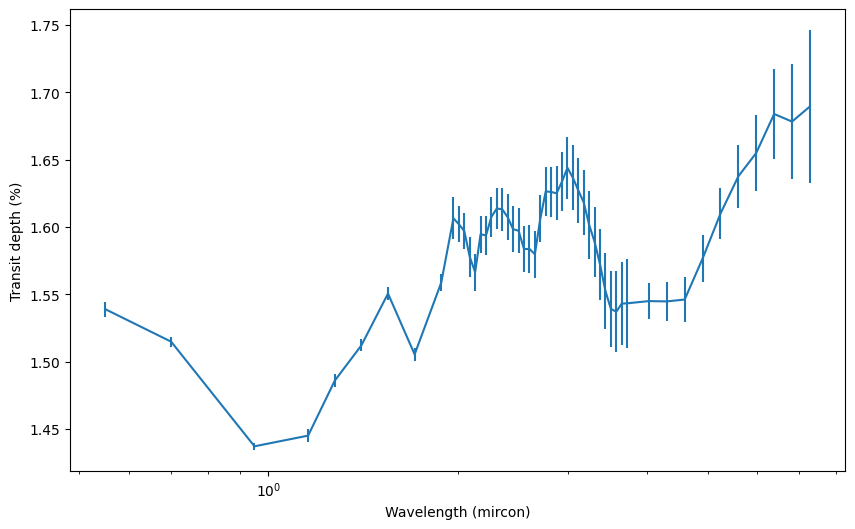

In [10]:
visualise_spectrum(spec_matrix[1])

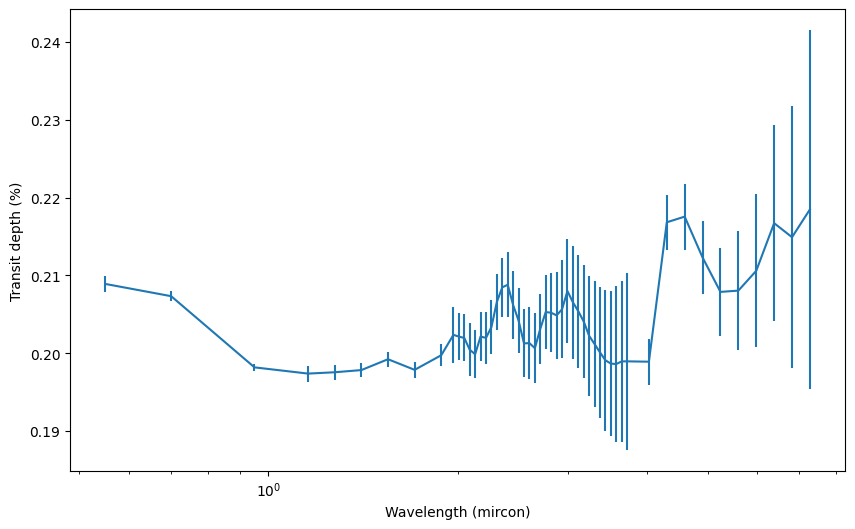

In [11]:
## lets look at another one
visualise_spectrum(spec_matrix[2])

it is immediately apparent that the average transit depth between two spectra can change for over an order of magnitude. The magnitude of the uncertainty can also change accordingly ( and is a function of the planetary system, brightness of the host star and instrument response function). 

## Pre-processing

### Settings

In [12]:
repeat = 5
threshold = 0.8 ## for train valid split.
N = len(spec_matrix)# train on the first 5000 data instances, remember only some examples are labelled, others are unlabelled!

We can safely discard wlgrid (wavelength grid) and wlwidth (width of wavelength) since they are unchanged in the dataset

### Extract Spectrum

In [13]:
# 1. Define target labels
target_labels = ['log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
num_targets = len(target_labels)

# 2. Identify ONLY the rows that have actual ground truth labels (no NaNs)
labelled_mask = soft_label_data[target_labels].notna().all(axis=1)
valid_indices = soft_label_data.index[labelled_mask].tolist()

print(f"Total rows: {len(spec_matrix)} | Labelled rows kept: {len(valid_indices)}")

# 3. Extract and filter spectra and noise
spectra_filtered = spec_matrix[valid_indices, :, 1]
noise_filtered = spec_matrix[valid_indices, :, 2]
wl_channels = len(spec_matrix[0, :, 0])

# 4. Extract and filter Star Radius (Rs)
Rs = aux_training_data[['star_radius_m']].copy()
Rs['star_radius'] = Rs['star_radius_m'] / RSOL
Rs = Rs.drop(['star_radius_m'], axis=1)
Rs_filtered = Rs.iloc[valid_indices, :]

# 5. Extract and filter Targets
targets_filtered = soft_label_data.loc[valid_indices, target_labels]

Total rows: 41423 | Labelled rows kept: 41423


In [14]:
# Split the data BEFORE calculating any means or standard deviations!
np.random.seed(SEED)
ind = np.random.rand(len(spectra_filtered)) < threshold

training_spectra = spectra_filtered[ind]
training_noise = noise_filtered[ind]
training_Rs = Rs_filtered[ind]
training_targets = targets_filtered[ind]

valid_spectra = spectra_filtered[~ind]
valid_Rs = Rs_filtered[~ind]
valid_targets = targets_filtered[~ind]

In [15]:
# Augment only the training data
repeat = 5
aug_spectra = augment_data_with_noise(training_spectra, training_noise, repeat)
aug_Rs = np.tile(training_Rs.values, (repeat, 1))
aug_targets = np.tile(training_targets.values, (repeat, 1))

In [16]:
# Calculate mean and standard deviation ONLY on the training set to prevent leakage
train_mean_spectra = np.mean(training_spectra)
train_std_spectra = np.std(training_spectra)

train_mean_Rs = training_Rs.mean().values.reshape(1, -1)
train_std_Rs = training_Rs.std().values.reshape(1, -1)

# We save these as we need them for inverse_transform later
targets_mean = training_targets.mean()
targets_std = training_targets.std()

train_mean_targets = targets_mean.values.reshape(1, -1)
train_std_targets = targets_std.values.reshape(1, -1)

# Standardize Spectra
std_aug_spectra = standardise(aug_spectra, train_mean_spectra, train_std_spectra).reshape(-1, wl_channels)
std_valid_spectra = standardise(valid_spectra, train_mean_spectra, train_std_spectra).reshape(-1, wl_channels)

# Standardize Radius
std_aug_Rs = standardise(aug_Rs, train_mean_Rs, train_std_Rs)
std_valid_Rs = standardise(valid_Rs.values, train_mean_Rs, train_std_Rs)

# Standardize Targets
std_aug_targets = standardise(aug_targets, train_mean_targets, train_std_targets)
std_valid_targets = standardise(valid_targets.values, train_mean_targets, train_std_targets)

## Train/valid Split

## Augment the dataset with noise (create multiple instances)
Observational noise from Ariel forms an important part of the challenge, any model must recognise that the observation are not absolute measurement and could vary (according to the uncertainty), as that will affect the uncertainty associated with our atmospheric targets. Here we try to incorporate these information by augmenting the data with the mean noise.

### Standardise the data

### spectra

### radius

### target
We are asking the model to provide estimates for 6 atmospheric targets. In this example will be performing a supervised learning task. 

# Setup network


### hyperparameter settings


In [17]:
batch_size= 32
lr= 1e-3
epochs = 30
filters = [32,64,64]
dropout = 0.1
# number of examples to generate in evaluation time (5000 is max for this competition)
N_samples = 5000

We followed [Yip et al.](https://iopscience.iop.org/article/10.3847/1538-3881/ac1744>) and adopted a simple CNN structure and loss function. 


In [18]:
model = MC_Convtrainer(wl_channels,num_targets,dropout,filters)

In [19]:
## compile model and run
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss='mse',)
model.fit(
    [std_aug_spectra, std_aug_Rs],
    std_aug_targets,
    validation_data=([std_valid_spectra, std_valid_Rs], std_valid_targets),
    batch_size=batch_size,
    epochs=epochs,
    shuffle=False,
)


Epoch 1/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1.0004 - val_loss: 0.9991
Epoch 2/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.0001 - val_loss: 0.9995
Epoch 3/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.0001 - val_loss: 1.0012
Epoch 4/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.8077 - val_loss: 0.4406
Epoch 5/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.4310 - val_loss: 0.3949
Epoch 6/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.3661 - val_loss: 0.3344
Epoch 7/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.3420 - val_loss: 0.3327
Epoch 8/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.3326 - val_loss: 0.3237
Epoch 9/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.3271 - val_loss: 0.3096
Epoch 10/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.3178 - val_loss: 0.3235
Epoch 11/30
5183/5183 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.3145 - val_loss: 0.3129
Epoch 12/30
5183/5183 ━━━━━━━

### Compile model and Train!

In [20]:
model.save_weights("cnn_whole_ariel_new.weights.h5")

In [21]:
index= np.arange(len(ind))
valid_index = index[~ind]

In [22]:
instances = N_samples
y_valid_distribution = np.zeros((instances, len(std_valid_spectra), num_targets ))
for i in tqdm(range(instances)):
    
    y_pred_valid = model([std_valid_spectra,std_valid_Rs],training=True)
    y_valid_distribution[i] += y_pred_valid

100%|██████████| 5000/5000 [03:09<00:00, 26.42it/s]


In [23]:
y_valid_distribution = y_valid_distribution.reshape(-1,num_targets)

In [24]:
y_pred_valid_org = transform_and_reshape(
    y_valid_distribution,
    targets_mean.to_numpy(), 
    targets_std.to_numpy(), 
    instances,
    N_testdata=len(std_valid_spectra)
)


In [25]:
tr1 = y_pred_valid_org
# weight takes into account the importance of each point in the tracedata. for now we just assume them to be equally weighted
weights1 = np.ones((tr1.shape[0],tr1.shape[1]))/np.sum(np.ones(tr1.shape[1]) )


In [26]:
trace_GT = h5py.File(os.path.join(training_GT_path, 'TraceData.hdf5'),"r")

## posterior scores 
This score accounts for 80% of the final score and it is based on the entire dataset.

In [27]:
posterior_scores = []
bounds_matrix = default_prior_bounds()[2:]

for idx, pl_idx in enumerate(valid_index):
    tr_GT = trace_GT[f'Planet_train{pl_idx+1}']['tracedata'][()]
    weights_GT = trace_GT[f'Planet_train{pl_idx+1}']['weights'][()]
    
    ## There are cases without ground truth, we will skip over them for this baseline
    if np.isnan(tr_GT).sum() >= 1:
        continue
        
    tr_GT = tr_GT[:, 2:]
    
    score = compute_posterior_loss(tr1[idx], weights1[idx], tr_GT, weights_GT, bounds_matrix)
    posterior_scores.append(score)
    
avg_posterior_score = np.mean(posterior_scores)

In [28]:
print(avg_posterior_score)

312.696710334789


In [29]:
def visualise_rmse_per_label(y_true, y_pred, labels):
    """
    Computes and visualises the Root Mean Squared Error (RMSE) for each target label.
    
    Args:
        y_true (ndarray or DataFrame): Ground truth values, shape (N_samples, N_targets).
        y_pred (ndarray): Predicted values. Can be shape (N_samples, N_targets) 
                          or (N_samples, N_instances, N_targets) if using MC Dropout.
        labels (list of str): List of target label names.
        
    Returns:
        list: The calculated RMSE scores for each label.
    """
    # Convert y_true to numpy array if it's a pandas DataFrame
    if hasattr(y_true, 'values'):
        y_true = y_true.values
        
    # If y_pred contains multiple MC Dropout instances, average them to get the mean prediction
    if len(y_pred.shape) == 3:
        y_pred = np.mean(y_pred, axis=1)
        
    rmse_scores = []
    
    # Calculate RMSE for each target label
    for i in range(len(labels)):
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        rmse_scores.append(np.sqrt(mse))
        
    # Visualisation
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, rmse_scores, color='cornflowerblue', edgecolor='black')
    
    # Add the value text on top of each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max(rmse_scores)*0.02), 
                 round(yval, 4), ha='center', va='bottom', fontsize=10)
                 
    plt.title('Root Mean Squared Error (RMSE) per Target Label', fontsize=14, pad=15)
    plt.xlabel('Atmospheric Targets', fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return rmse_scores

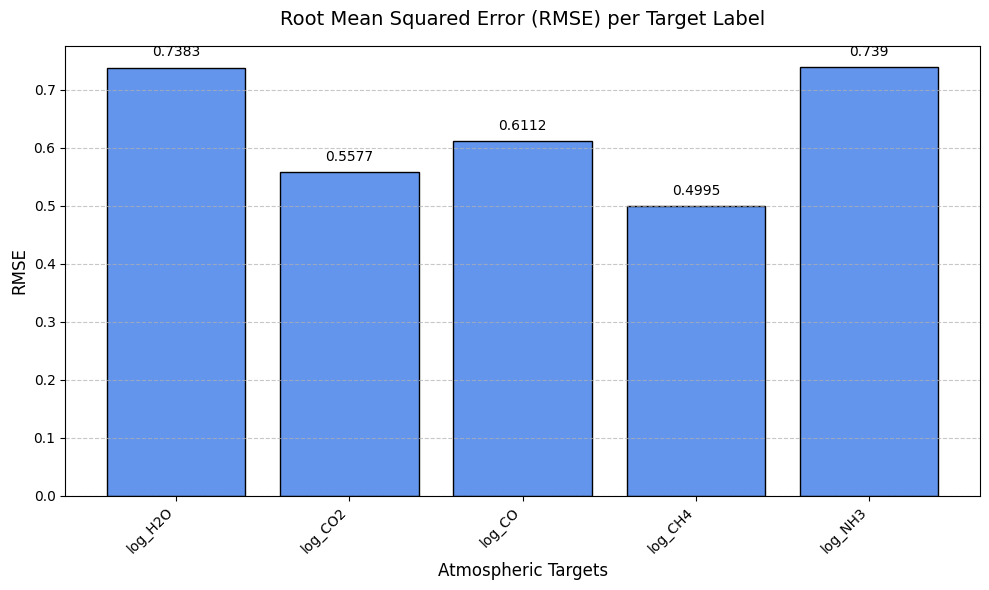

In [30]:
# Execute the visualisation
rmse_results = visualise_rmse_per_label(
    y_true=valid_targets, 
    y_pred=y_pred_valid_org, 
    labels=target_labels
)

## spectral scores 
This score accounts for 20% of the final score and it is based on a pre-selected, classified subset of the entire dataset.
It takes a while to compute the score, even for 100 samples, so we will randomly draw 20 in this case to illustrate the idea.

**CAUTION: To use this metric you must have taurex and their linelists available on your local environment. Please refer to README.MD on the github repo for more information**

In [ ]:
N_examples = 10 ## number of test examples to go through
N_samples = 10 ## number of quantiles to sample (fixed to 10 in the competition)
q_list = np.linspace(0.01,0.99,N_samples)
## beta - weight of the posterior loss [0,1], and the weight of spectral loss will decrease accordingly. 
beta = 0.8

In [ ]:
## Path variables
opacity_path="PATH/TO/xsec/"
CIA_path="PATH/TO/cia/HITRAN"


In [ ]:
## read in spectral grid
ariel_wlgrid, ariel_wlwidth, ariel_wngrid, ariel_wnwidth = ariel_resolution()
## Initialise base T3 model for ADC2023
fm = initialise_forward_model(opacity_path, CIA_path)

In [ ]:
# raed auxillary information from the input file (Provided from ADC2023)
aux_df = aux_training_data
# ensure the dimensionality matches forward model's input.
Rs = aux_df['star_radius_m']/RSOL
# Rp = aux_df['planet_radius_m']/RJUP
Mp = aux_df['planet_mass_kg']/MJUP

In [ ]:
## select few random validation data for spectral loss computation

In [ ]:
spectral_scores = []
bounds_matrix = default_prior_bounds()
for idx, pl_idx in enumerate(valid_index):
    ## put an early stop here as it will take forever to go through 5000 examples. 
    if idx == 20:
        break
    tr_GT = trace_GT[f'Planet_train{pl_idx+1}']['tracedata'][()]
    weights_GT = trace_GT[f'Planet_train{pl_idx+1}']['weights'][()]
    # again to avoid unlabelled data
    if np.isnan(tr_GT).sum() == 1:
        continue

    proxy_compute_spectrum = setup_dedicated_fm(fm, idx, Rs, Mp, ariel_wngrid, ariel_wnwidth )

    score = compute_spectral_loss(tr1[idx], weights1[idx], tr_GT,weights_GT,bounds_matrix,proxy_compute_spectrum,q_list)
    spectral_scores.append(score)
avg_spectral_score = np.mean(spectral_scores)

In [ ]:
final_score = (1-beta)*avg_spectral_score + beta *avg_posterior_score
print(f"final loss is {final_score:.4f}")

# Generate prediction for leaderboard

### load leaderboard data

In [ ]:
spec_test_data = h5py.File(os.path.join(test_path,'SpectralData.hdf5'),"r")
aux_test_data = pd.read_csv(os.path.join(test_path,'AuxillaryTable.csv'))

### same pre-processing as before...

In [ ]:
test_spec_matrix = to_observed_matrix(spec_test_data,aux_test_data )

In [ ]:
std_test_spectra = standardise(test_spec_matrix[:,:,1], global_mean, global_std)

In [ ]:
test_Rs = aux_test_data[['star_radius_m']]
## we would prefer to use RSol 
test_Rs['star_radius'] = test_Rs['star_radius_m']/RSOL
test_Rs = test_Rs.drop(['star_radius_m'],axis=1)
std_test_Rs= standardise(test_Rs, mean_Rs, stdev_Rs)


## Predict and postprocess
We will sample 5000 times by activating dropout at inference phase. This is done explicitly via training = True. Note that in the competition, any sample size bigger than 5000 will NOT be accepted. However, the sample size must have a minimum of 1000 points to be a valid submission. 

In [ ]:
tf.keras.utils.set_random_seed(SEED)

In [ ]:
instances = N_samples
y_pred_distribution = np.zeros((instances, len(std_test_spectra), num_targets ))
for i in tqdm(range(instances)):
    
    y_pred = model([std_test_spectra,std_test_Rs],training=True)
    y_pred_distribution[i] += y_pred


In [ ]:
y_pred_distribution = y_pred_distribution.reshape(-1,num_targets)

In [ ]:
y_pred_test_org = transform_and_reshape(y_pred_distribution,targets_mean, targets_std,instances,N_testdata=len(std_test_spectra))

## Package output into desired format
We follow specific formats in the competition, to help make the process as painless as possible, we have included a few helper functions to make sure you have the right format in place for the submission. 

In [ ]:
tracedata = y_pred_test_org
# weight takes into account the importance of each point in the tracedata. 
weight = np.ones((tracedata.shape[0],tracedata.shape[1]))/np.sum(np.ones(tracedata.shape[1]) )

submission = to_competition_format(tracedata, 
                                        weight, 
                                        name="submission.hdf5")

## check!

## Future work

There are different direction to take from here on, let us summarise the shortcomings of this model:
- The data preprocessing is quite simplistic and could have invested with more efforts.
- we have only used 5000 data points, instead of the full dataset
- we didnt train the model with results from the retrieval ( Tracedata.hdf5), which are the GT for this competition.
- The conditional distribution from MCDropout is very restricted and Gaussian-like
- So far we havent considered the atmospheric targets as a joint distribution
- We have only used stellar radius from the auxillary information
- We have not done any hyperparameter tuning 
- the train test split here is not clean, as in, we split the data after we have augmented the data, which results in information leakage to the validation data. There is no leakage to the test data though.